In [1]:
import gc
import math
import os
from datetime import datetime

import polars as pl
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.util.constants import PATH_RAW_ALL, DATA_PATH, FIXED_LGB_PARAMETERS
from src.util.common import grouped_spearman_correlation, save_as_pickle, customise_plot_style
from util.common import load_from_pickle

In [2]:
NUMBER_OF_FOLDS = 5
ERAS_TO_PURGE = 8  # 8 weeks

We save files in tmp to free up memory.

In [3]:
df_all = pl.read_parquet(PATH_RAW_ALL)

df_all = df_all.filter(pl.col("target").is_not_null())
df_all = df_all.drop([col for col in df_all.columns if "target_" in col] + ["data_type", 'id'])
df_all.write_parquet(DATA_PATH / f"tmp/df_all.parquet")

In [4]:
feature_names = [x for x in df_all.columns if 'feature' in x]

eras = df_all['era'].unique().to_list()
start_eras = [df_all['era'][round(df_all.shape[0] * x / NUMBER_OF_FOLDS)] for x in range(NUMBER_OF_FOLDS)] + [df_all['era'].max() + 1]

save_as_pickle(feature_names, DATA_PATH / "tmp/feature_names.pkl")

In [5]:
# We predict across all eras, using "future" data for training
# This does not reflect a live environment, but with purging 4 weeks,
# it still gives us a good idea of performance over the whole period
for fold in range(NUMBER_OF_FOLDS):
    print(f"{datetime.now().strftime('%H:%M:%S')} . . . Preparing data for fold: {fold}")
    train_eras = [x for x in eras if x < (start_eras[fold] - ERAS_TO_PURGE) or x > (start_eras[fold + 1] + ERAS_TO_PURGE)]
    validate_eras = [x for x in eras if start_eras[fold] <= x < start_eras[fold + 1]]

    df_train = df_all.filter(pl.col('era').is_in(train_eras))
    X_train = df_train[feature_names].to_numpy()
    y_train = df_train['target'].to_numpy()
    del df_train
    save_as_pickle(X_train, DATA_PATH / f"tmp/X_train_{fold}.pkl")
    save_as_pickle(y_train, DATA_PATH / f"tmp/y_train_{fold}.pkl")
    del X_train, y_train
    gc.collect()

    df_validate = df_all.filter(pl.col('era').is_in(validate_eras))
    df_validate.write_parquet(DATA_PATH / f"tmp/df_validate_{fold}.parquet")
    del df_validate
    gc.collect()

del df_all
gc.collect()

01:01:33 . . . fold: 0
01:02:03 . . . fold: 1
01:03:03 . . . fold: 2
01:04:23 . . . fold: 3
01:05:37 . . . fold: 4


0

In [3]:
num_boost_round_space = [10, 33, 100]
num_leaves_space = [2**(x*3) - 1 for x in range(1, 4)]

In [4]:
results = {(num_boost_round, num_leaves): [] for num_boost_round in num_boost_round_space for num_leaves in num_leaves_space}
feature_names = load_from_pickle(DATA_PATH / f"tmp/feature_names.pkl")

for num_leaves in num_leaves_space:
    parameters = {
        **FIXED_LGB_PARAMETERS,
        'num_leaves': num_leaves,
        'num_boost_round': max(num_boost_round_space)
    }
    print(f"{datetime.now().strftime('%H:%M:%S')} . . . Number of leaves: {num_leaves}")

    for fold in range(NUMBER_OF_FOLDS):
        print(f"{datetime.now().strftime('%H:%M:%S')} . . . fold: {fold}")
        X_train = load_from_pickle(DATA_PATH / f"tmp/X_train_{fold}.pkl")
        y_train = load_from_pickle(DATA_PATH / f"tmp/y_train_{fold}.pkl")
        lgb_train = lgb.Dataset(X_train, label=y_train)

        print(f"{datetime.now().strftime('%H:%M:%S')} . . . Training model...")
        model = lgb.train(
            params=parameters,
            train_set=lgb_train,
            num_boost_round=parameters['num_boost_round']
        )
        del lgb_train
        gc.collect()

        df_validate = pl.read_parquet(DATA_PATH / f"tmp/df_validate_{fold}.parquet")
        for num_boost_round in num_boost_round_space:
            df_validate = df_validate.with_columns(
                prediction=model.predict(df_validate[feature_names].to_numpy(), num_iteration=num_boost_round)
            )

            correlations = grouped_spearman_correlation(
                df_validate.select('prediction').to_series(),
                df_validate.select('target').to_series(),
                df_validate.select('era').to_series()
            ).to_list()

            results[(num_boost_round, num_leaves)].extend(correlations)

            print(f'{datetime.now().strftime("%H:%M:%S")} . . . Model for num_leaves={num_leaves}, num_boost_round={num_boost_round}, and fold {fold} done.')
        del df_validate
        gc.collect()

    (DATA_PATH / 'tmp').mkdir(parents=True, exist_ok=True)
    save_as_pickle(results, DATA_PATH / 'tmp/performance_over_time.pkl')

01:38:53 . . . Number of leaves: 7
01:38:53 . . . fold: 0
01:38:56 . . . Training model...
01:55:45 . . . Model for num_leaves=7, num_boost_round=10, and fold 0 done.
01:55:52 . . . Model for num_leaves=7, num_boost_round=33, and fold 0 done.
01:55:59 . . . Model for num_leaves=7, num_boost_round=100, and fold 0 done.
01:55:59 . . . fold: 1
01:56:03 . . . Training model...
02:12:47 . . . Model for num_leaves=7, num_boost_round=10, and fold 1 done.
02:12:54 . . . Model for num_leaves=7, num_boost_round=33, and fold 1 done.
02:13:01 . . . Model for num_leaves=7, num_boost_round=100, and fold 1 done.
02:13:01 . . . fold: 2
02:13:04 . . . Training model...
02:29:27 . . . Model for num_leaves=7, num_boost_round=10, and fold 2 done.
02:29:34 . . . Model for num_leaves=7, num_boost_round=33, and fold 2 done.
02:29:42 . . . Model for num_leaves=7, num_boost_round=100, and fold 2 done.
02:29:42 . . . fold: 3
02:29:45 . . . Training model...
02:46:23 . . . Model for num_leaves=7, num_boost_round

In [5]:
# Drop all sub-lists from the list `results` that contain NaNs
results = [result for result in results.values() if not any(math.isnan(value) for value in result)]
number_of_models = len(num_leaves_space) * len(num_boost_round_space)
print(f'{number_of_models - len(results)} out of {number_of_models} model results dropped due to NaNs.')

df_results = pl.DataFrame(
    results,
    [f'model_{i}' for i in range(len(results))],
    orient='col'
)

0 out of 9 model results dropped due to NaNs.


In [6]:
df_performance_corr = df_results.corr()
# HACKY, but does the trick: mask the diagonal
for i in range(len(df_performance_corr.columns)):
    df_performance_corr[i, i] = None


print(df_performance_corr.min().transpose().min())
print(df_performance_corr.median().transpose().median())
print(df_performance_corr.max().transpose().max())

shape: (1, 1)
┌──────────┐
│ column_0 │
│ ---      │
│ f64      │
╞══════════╡
│ 0.280655 │
└──────────┘
shape: (1, 1)
┌──────────┐
│ column_0 │
│ ---      │
│ f64      │
╞══════════╡
│ 0.598032 │
└──────────┘
shape: (1, 1)
┌──────────┐
│ column_0 │
│ ---      │
│ f64      │
╞══════════╡
│ 0.893913 │
└──────────┘


The performance of models is highly correlated.

In [7]:
df_ranking_corr = df_results.transpose().corr()
# HACKY, but does the trick: mask the diagonal
for i in range(len(df_ranking_corr.columns)):
    df_ranking_corr[i, i] = None

print(df_ranking_corr.min().transpose().min())
print(df_ranking_corr.median().transpose().median())
print(df_ranking_corr.max().transpose().max())

shape: (1, 1)
┌───────────┐
│ column_0  │
│ ---       │
│ f64       │
╞═══════════╡
│ -0.987217 │
└───────────┘
shape: (1, 1)
┌──────────┐
│ column_0 │
│ ---      │
│ f64      │
╞══════════╡
│ 0.335738 │
└──────────┘
shape: (1, 1)
┌──────────┐
│ column_0 │
│ ---      │
│ f64      │
╞══════════╡
│ 0.995778 │
└──────────┘


The ranking of model performance is also correlated, but with strongly negative values as well.

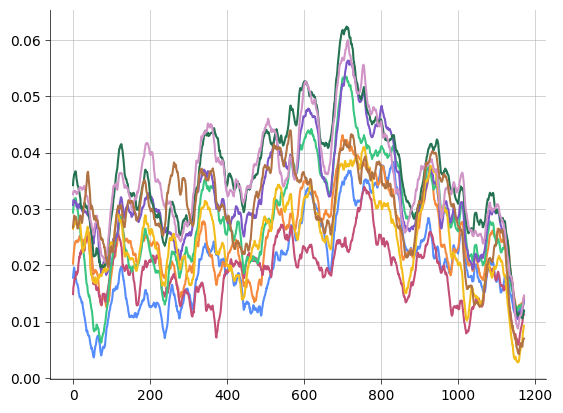

In [8]:
df_results_copy = df_results
for i in range(len(df_results_copy.columns)):
    df_results_copy = df_results_copy.with_columns(
        pl.col(f"model_{i}").rolling_mean(window_size=52).alias(f"mean_{i}")
    )

df_results_copy = df_results_copy[[x for x in df_results_copy.columns if 'mean' in x]].drop_nulls()

customise_plot_style()
sns.lineplot(data=df_results_copy, dashes=False, legend=False)
plt.show()

There is a long-term downward trend in performance over the last ca. 9 years.

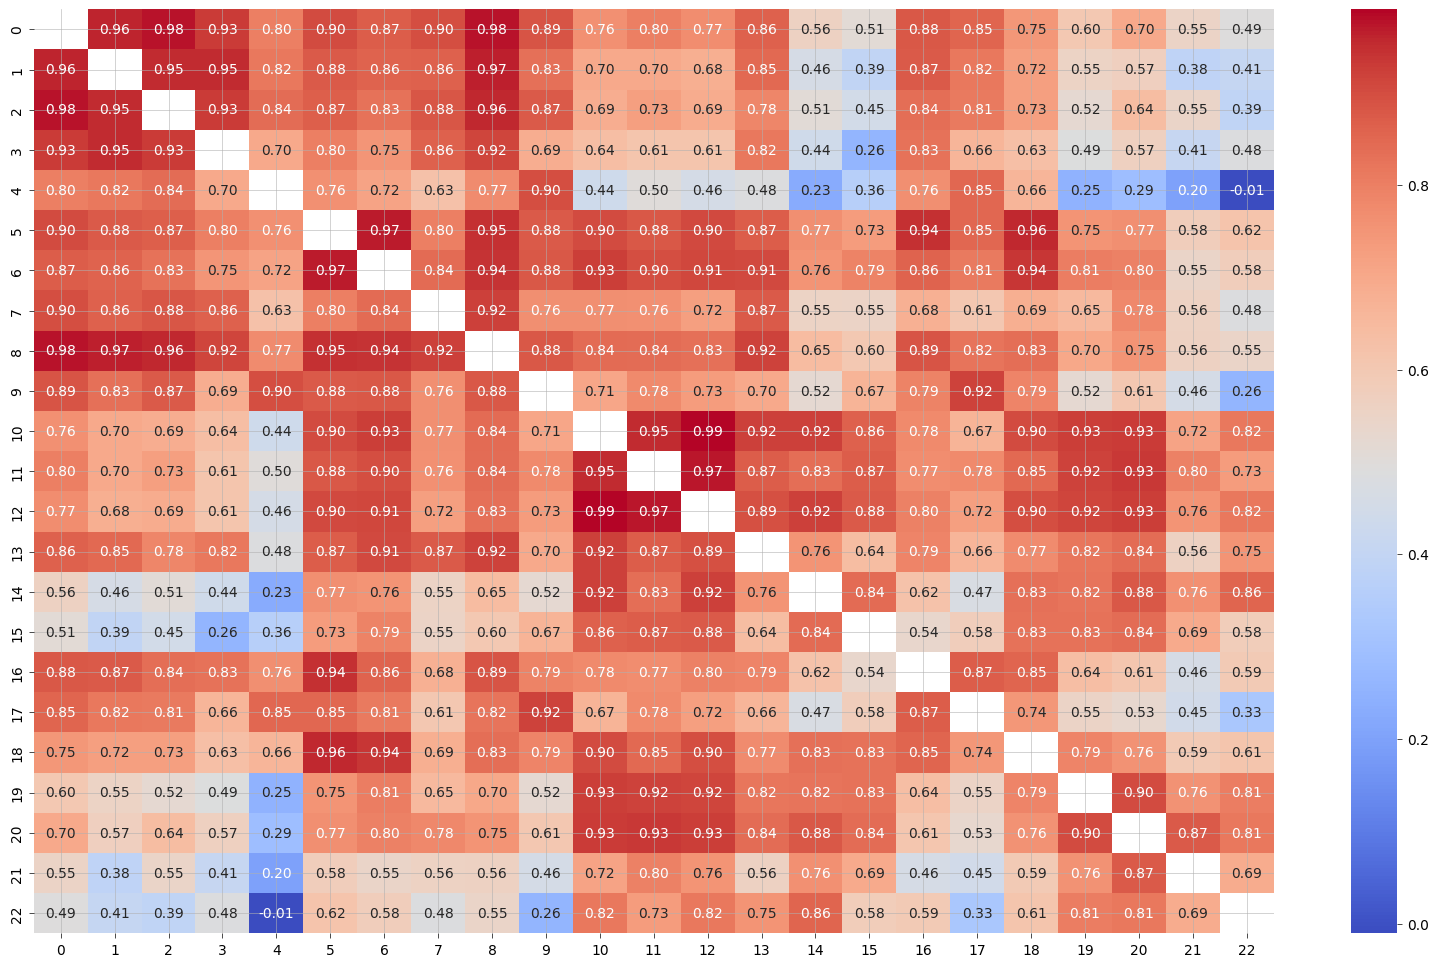

In [11]:
df_all = pl.read_parquet(DATA_PATH / f"tmp/df_all.parquet")
eras = df_all['era'].unique().to_list()

number_of_groups = int(len(eras) / 52.18)  # approximate years

start_eras = [df_all['era'][round(df_all.shape[0] * x / number_of_groups)] for x in range(number_of_groups)] + [df_all['era'].max() + 1]

# assign each era to its group
group_lengths = [start_eras[i+1]-start_eras[i] for i in range(number_of_groups)]
group_labels = [i for i, length in enumerate(group_lengths) for _ in range(length)]
df_results = df_results.with_columns(
    index=pl.Series(group_labels)
)

# group by index and get column-wise mean
df_performance_by_group = (df_results.group_by('index', maintain_order=True)
                           .agg(pl.all().mean())[:, 1:len(df_results.columns)+1]
                           .transpose())

df_corr = df_performance_by_group.corr()

plt.figure(figsize=(20, 12))

# show the values in the heatmap, rounded to two decimals
sns.heatmap(df_corr.to_numpy(),
            mask=np.eye(df_corr.shape[0], dtype=bool),  # Create a mask for the diagonal to hide trivial perfect correlations
            annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In the second half, almost all correlations are above 33%, and most are above 50%.

Conclusion: I will simply use the last 45% for three validation/test folds.

In [17]:
# Free up ca. 100GB
for fold in range(1, NUMBER_OF_FOLDS):
    os.remove(DATA_PATH / f"tmp/X_train_{fold}.pkl")
    os.remove(DATA_PATH / f"tmp/y_train_{fold}.pkl")
    os.remove(DATA_PATH / f"tmp/df_validate_{fold}.parquet")
os.remove(DATA_PATH / f"tmp/df_all.parquet")
os.remove(DATA_PATH / f"tmp/feature_names.pkl")